<a href="https://colab.research.google.com/github/Abohmeed06/The-Metabolic-Syndrome-Challenge/blob/main/Dataproject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1**



In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV

# Load & Explore

In [ ]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nColumn types:\n", train.dtypes)
print("\nMissing values in train:\n", train.isnull().sum())
print("\nTarget distribution:\n", train['MetabolicSyndrome'].value_counts())

Train shape: (1920, 15)
Test shape: (481, 15)

Column types:
 seqn                   int64
Age                    int64
Sex                   object
Marital               object
Income               float64
Race                  object
WaistCirc            float64
BMI                  float64
Albuminuria            int64
UrAlbCr              float64
UricAcid             float64
BloodGlucose           int64
HDL                    int64
Triglycerides          int64
MetabolicSyndrome      int64
dtype: object

Missing values in train:
 seqn                   0
Age                    0
Sex                    0
Marital              165
Income                95
Race                   0
WaistCirc             65
BMI                   23
Albuminuria            0
UrAlbCr                0
UricAcid               0
BloodGlucose           0
HDL                    0
Triglycerides          0
MetabolicSyndrome      0
dtype: int64

Target distribution:
 MetabolicSyndrome
0    1263
1     657
Name: count, 

# Separate Features & **Target**

In [ ]:
X = train.drop(columns=['seqn', 'MetabolicSyndrome'])
y = train['MetabolicSyndrome']

test_ids    = test['id']
X_test_raw  = test.drop(columns=['id', 'seqn'])

# Feature Engineering

In [ ]:
# Nayer Look HERE !!!!!!!!!!!!!!!!!!!!


def add_features(df):
    df = df.copy()

    # Original features
    df['BMI_Waist']        = df['BMI'] * df['WaistCirc']
    df['Glucose_TG_ratio'] = df['BloodGlucose'] / (df['Triglycerides'] + 1)
    df['HDL_TG_ratio']     = df['HDL'] / (df['Triglycerides'] + 1)

    # Clinical threshold flags (IDF metabolic syndrome criteria)
    df['AbdominalObese']  = (df['WaistCirc'] > 94).astype(int)
    df['HighTG']          = (df['Triglycerides'] >= 150).astype(int)
    df['LowHDL']          = (df['HDL'] < 40).astype(int)
    df['HighGlucose']     = (df['BloodGlucose'] >= 100).astype(int)
    df['Albuminuria_flag']= (df['Albuminuria'] >= 2).astype(int)
    df['RiskScore']       = (df['AbdominalObese'] + df['HighTG'] +
                             df['LowHDL'] + df['HighGlucose'] +
                             df['Albuminuria_flag'])
    # Ratio features
    df['TG_HDL_ratio'] = df['Triglycerides'] / (df['HDL'] + 1)
    df['Glucose_HDL']  = df['BloodGlucose'] / (df['HDL'] + 1)

    # Log-transform skewed features
    for col in ['UrAlbCr', 'Triglycerides', 'UricAcid']:
        df[f'log_{col}'] = np.log1p(df[col])

    return df

X          = add_features(X)
X_test_raw = add_features(X_test_raw)


# **Define** Column Types




In [ ]:
categorical_cols = ['Sex', 'Marital', 'Race']
numerical_cols   = [c for c in X.columns if c not in categorical_cols]

print(f"\nNumerical features ({len(numerical_cols)}):", numerical_cols)
print(f"Categorical features: {categorical_cols}")


Numerical features (24): ['Age', 'Income', 'WaistCirc', 'BMI', 'Albuminuria', 'UrAlbCr', 'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides', 'BMI_Waist', 'Glucose_TG_ratio', 'HDL_TG_ratio', 'AbdominalObese', 'HighTG', 'LowHDL', 'HighGlucose', 'Albuminuria_flag', 'RiskScore', 'TG_HDL_ratio', 'Glucose_HDL', 'log_UrAlbCr', 'log_Triglycerides', 'log_UricAcid']
Categorical features: ['Sex', 'Marital', 'Race']


# Build Preprocessing **Pipeline**

In [ ]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train_raw.shape[0])
print("Val size:", X_val_raw.shape[0])

Train size: 1536
Val size: 384


# Train/Validation **Split**

In [ ]:
numerical_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  RobustScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])


# Fit & **Transform**

In [ ]:
X_train = preprocessor.fit_transform(X_train_raw)
X_val   = preprocessor.transform(X_val_raw)
X_test  = preprocessor.transform(X_test_raw)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1536, 37)
X_val shape: (384, 37)
X_test shape: (481, 37)


# Verify (no NaNs)

In [ ]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())

NaNs in X_train: 0
NaNs in X_val: 0
NaNs in X_test: 0


# Export for **Teammates**

In [ ]:
np.save('X_train.npy', X_train)
np.save('X_val.npy', X_val)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train.values)
np.save('y_val.npy', y_val.values)
test_ids.to_csv('test_ids.csv', index=False)

print("All files saved successfully!")

All files saved successfully!


# **Task 2**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
ks      = [7, 9, 11, 13, 15, 17, 19, 21, 25, 31, 41, 51, 67, 71]
metrics = [ 'euclidean', 'manhattan']
weights = ['distance']

results_knn = []
for k in ks:
    for metric in metrics:
        for w in weights:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=w)
            knn.fit(X_train, y_train)
            proba = knn.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, proba)
            results_knn.append((k, metric, w, score))
            print(f"k={k}, metric={metric}, weights={w}, AUC={score:.4f}")

results_knn.sort(key=lambda x: x[3], reverse=True)
print("\nTop 5 kNN configs:")
for r in results_knn[:5]:
    print(f"  k={r[0]}, metric={r[1]}, weights={r[2]}, AUC={r[3]:.4f}")

k=7, metric=euclidean, weights=distance, AUC=0.9047
k=7, metric=manhattan, weights=distance, AUC=0.9245
k=9, metric=euclidean, weights=distance, AUC=0.9081
k=9, metric=manhattan, weights=distance, AUC=0.9284
k=11, metric=euclidean, weights=distance, AUC=0.9182
k=11, metric=manhattan, weights=distance, AUC=0.9315
k=13, metric=euclidean, weights=distance, AUC=0.9224
k=13, metric=manhattan, weights=distance, AUC=0.9322
k=15, metric=euclidean, weights=distance, AUC=0.9220
k=15, metric=manhattan, weights=distance, AUC=0.9319
k=17, metric=euclidean, weights=distance, AUC=0.9280
k=17, metric=manhattan, weights=distance, AUC=0.9339
k=19, metric=euclidean, weights=distance, AUC=0.9287
k=19, metric=manhattan, weights=distance, AUC=0.9348
k=21, metric=euclidean, weights=distance, AUC=0.9289
k=21, metric=manhattan, weights=distance, AUC=0.9326
k=25, metric=euclidean, weights=distance, AUC=0.9300
k=25, metric=manhattan, weights=distance, AUC=0.9354
k=31, metric=euclidean, weights=distance, AUC=0.93

# Best model selection

In [ ]:
best_k   = results_knn[0]
best_knn = KNeighborsClassifier(n_neighbors=best_k[0], metric=best_k[1], weights=best_k[2])
best_knn.fit(X_train, y_train)

cal_knn     = CalibratedClassifierCV(best_knn, method='isotonic', cv=5)
cal_knn.fit(X_train, y_train)
knn_y_proba = cal_knn.predict_proba(X_val)[:, 1]

# Outputs for Task 4

In [ ]:
thresholds = np.arange(0.2, 0.8, 0.01)
best_thresh_knn, best_f1_knn = 0.5, 0
for t in thresholds:
    pred = (knn_y_proba >= t).astype(int)
    f1   = f1_score(y_val, pred)
    if f1 > best_f1_knn:
        best_f1_knn, best_thresh_knn = f1, t

knn_y_pred = (knn_y_proba >= best_thresh_knn).astype(int)

print(f"\nBest kNN → k={best_k[0]}, metric={best_k[1]}, weights={best_k[2]}")
print(f"  Optimal threshold : {best_thresh_knn:.2f}")
print(f"  Val AUC           : {roc_auc_score(y_val, knn_y_proba):.4f}")
print(f"  Val F1            : {f1_score(y_val, knn_y_pred):.4f}")

# Save kNN submission
knn_test_proba = cal_knn.predict_proba(X_test)[:, 1]
knn_test_preds = (knn_test_proba >= best_thresh_knn).astype(int)
submission_knn = pd.DataFrame({'id': test_ids.values, 'MetabolicSyndrome': knn_test_preds})
submission_knn.to_csv('knn_submission.csv', index=False)

print("knn_submission.csv saved!")


Best kNN → k=71, metric=manhattan, weights=distance
  Optimal threshold : 0.34
  Val AUC           : 0.9426
  Val F1            : 0.8288
knn_submission.csv saved!


# **Task 3**

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Hyperparameter Tuning

In [ ]:
var_smoothing_values = np.logspace(0, -9, num=10)

neg_ratio = (y_train == 0).sum() / len(y_train)
pos_ratio = (y_train == 1).sum() / len(y_train)

priors_options = {
    'None':       None,
    'Equal':      [0.5, 0.5],
    'data_dist':  [neg_ratio, pos_ratio],
    'boost_pos':  [0.40, 0.60],
    'boost_more': [0.35, 0.65],
}

# 2. Run tuning loop
results_nb = []
for vs in var_smoothing_values:
    for prior_name, prior_val in priors_options.items():

        # Train model
        model = GaussianNB(var_smoothing=vs, priors=prior_val)
        model.fit(X_train, y_train)

        # Evaluate
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]

        results_nb.append({
            'var_smoothing': vs,
            'priors':        prior_name,
            'auc':           round(roc_auc_score(y_val, y_prob), 4),
            'f1':            round(f1_score(y_val, y_pred), 4),
            'accuracy':      round(accuracy_score(y_val, y_pred), 4),
            'model':         model
        })

# 3. Display results
results_nb_df = pd.DataFrame(results_nb).drop(columns='model')
print(results_nb_df.to_string(index=False))

 var_smoothing     priors    auc     f1  accuracy
  1.000000e+00       None 0.9018 0.0725    0.6667
  1.000000e+00      Equal 0.9018 0.0725    0.6667
  1.000000e+00  data_dist 0.9018 0.0725    0.6667
  1.000000e+00  boost_pos 0.9018 0.6235    0.5911
  1.000000e+00 boost_more 0.9018 0.5087    0.3411
  1.000000e-01       None 0.9118 0.0725    0.6667
  1.000000e-01      Equal 0.9118 0.1268    0.6771
  1.000000e-01  data_dist 0.9118 0.0725    0.6667
  1.000000e-01  boost_pos 0.9118 0.2368    0.6979
  1.000000e-01 boost_more 0.9118 0.4862    0.7578
  1.000000e-02       None 0.9143 0.3614    0.7240
  1.000000e-02      Equal 0.9143 0.4862    0.7578
  1.000000e-02  data_dist 0.9143 0.3614    0.7240
  1.000000e-02  boost_pos 0.9143 0.5521    0.7760
  1.000000e-02 boost_more 0.9143 0.6100    0.7969
  1.000000e-03       None 0.9094 0.6991    0.8229
  1.000000e-03      Equal 0.9094 0.7069    0.8229
  1.000000e-03  data_dist 0.9094 0.6991    0.8229
  1.000000e-03  boost_pos 0.9094 0.7039    0.8203


# Best model selection

In [ ]:
results_nb.sort(key=lambda x: x['auc'], reverse=True)
best_nb_info = results_nb[0]

print("\nBest NB:")
print(f"  var_smoothing : {best_nb_info['var_smoothing']}")
print(f"  priors        : {best_nb_info['priors']}")
print(f"  AUC           : {best_nb_info['auc']}")
print(f"  F1            : {best_nb_info['f1']}")
print(f"  Accuracy      : {best_nb_info['accuracy']}")

best_nb_raw = best_nb_info['model']

cal_nb      = CalibratedClassifierCV(best_nb_raw, method='isotonic', cv=5)
cal_nb.fit(X_train, y_train)

nb_y_proba  = cal_nb.predict_proba(X_val)[:, 1]

best_thresh_nb, best_f1_nb = 0.5, 0

for t in thresholds:
    pred = (nb_y_proba >= t).astype(int)
    f1   = f1_score(y_val, pred)
    if f1 > best_f1_nb:
        best_f1_nb, best_thresh_nb = f1, t

nb_y_pred = (nb_y_proba >= best_thresh_nb).astype(int)

print(f"\nCalibrated NB:")
print(f"  Optimal threshold : {best_thresh_nb:.2f}")
print(f"  Val AUC           : {roc_auc_score(y_val, nb_y_proba):.4f}")
print(f"  Val F1            : {f1_score(y_val, nb_y_pred):.4f}")



Best NB:
  var_smoothing : 0.01
  priors        : None
  AUC           : 0.9143
  F1            : 0.3614
  Accuracy      : 0.724

Calibrated NB:
  Optimal threshold : 0.37
  Val AUC           : 0.9137
  Val F1            : 0.7875


# Outputs for Task 4

In [ ]:
nb_test_preds = (cal_nb.predict_proba(X_test)[:, 1] >= best_thresh_nb).astype(int)
submission_nb = pd.DataFrame({'id': test_ids.values, 'MetabolicSyndrome': nb_test_preds})
submission_nb.to_csv('nb_submission.csv', index=False)

print("nb_submission.csv saved! Shape:", submission_nb.shape)
print(submission_nb['MetabolicSyndrome'].value_counts())

nb_submission.csv saved! Shape: (481, 2)
MetabolicSyndrome
0    276
1    205
Name: count, dtype: int64


# **Task 4**

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# evaluating models using metrics

In [ ]:
print("kNN results:")

print("Accuracy:", accuracy_score(y_val, knn_y_pred))
print("Precision:", precision_score(y_val, knn_y_pred))
print("Recall:", recall_score(y_val, knn_y_pred))
print("F1-score:", f1_score(y_val, knn_y_pred))

kNN results:
Accuracy: 0.8697916666666666
Precision: 0.7515527950310559
Recall: 0.9236641221374046
F1-score: 0.8287671232876712


In [ ]:
print("\nNaive Bayes results:")

print("Accuracy:", accuracy_score(y_val, nb_y_pred))
print("Precision:", precision_score(y_val, nb_y_pred))
print("Recall:", recall_score(y_val, nb_y_pred))
print("F1-score:", f1_score(y_val, nb_y_pred))


Naive Bayes results:
Accuracy: 0.8411458333333334
Precision: 0.7243589743589743
Recall: 0.8625954198473282
F1-score: 0.7874564459930313


# Calculate specificity

In [ ]:
from sklearn.metrics import confusion_matrix

def calc_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

print("kNN Specificity:", calc_specificity(y_val, knn_y_pred))
print("NB Specificity:", calc_specificity(y_val, nb_y_pred))

kNN Specificity: 0.841897233201581
NB Specificity: 0.8300395256916996


# Plot confusion matrix

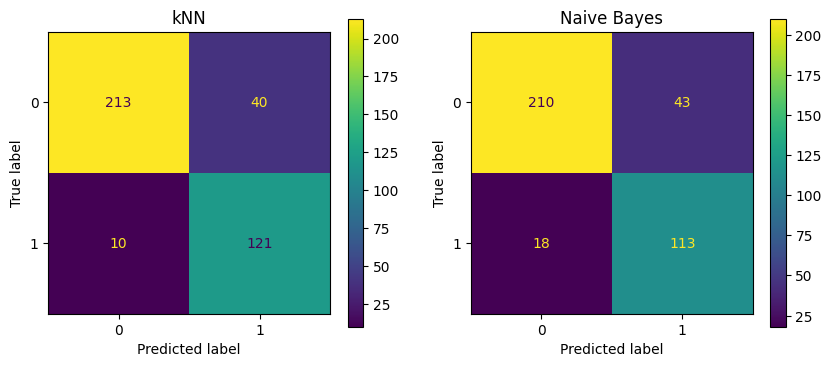

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(y_val, knn_y_pred, ax=ax[0])
ax[0].set_title("kNN")

ConfusionMatrixDisplay.from_predictions(y_val, nb_y_pred, ax=ax[1])
ax[1].set_title("Naive Bayes")

plt.show()

# Plot ROC curve

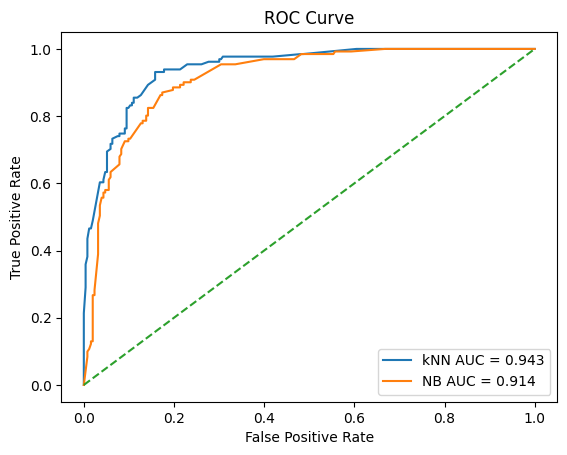

In [ ]:
# kNN
fpr_knn, tpr_knn, _ = roc_curve(y_val, knn_y_proba)
auc_knn = auc(fpr_knn, tpr_knn)

# NB
fpr_nb, tpr_nb, _ = roc_curve(y_val, nb_y_proba)
auc_nb = auc(fpr_nb, tpr_nb)

plt.plot(fpr_knn, tpr_knn, label="kNN AUC = " + str(round(auc_knn, 3)))
plt.plot(fpr_nb, tpr_nb, label="NB AUC = " + str(round(auc_nb, 3)))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Model Evaluation

I evaluated kNN and Naive Bayes using accuracy, precision, recall, F1-score, and AUC.

kNN performed better overall and had a higher AUC score, which means it separated the classes better than Naive Bayes.

I chose kNN as the final model because it gave more balanced and reliable results.

Naive Bayes assumes features are independent, but in this dataset many features are related, which affected its performance.


Independence vs. Correlation
Naive Bayes assumes that features are independent, but in this dataset many features are related, such as BMI and Waist Circumference. Because of this, Naive Bayes may struggle when linked features affect the prediction together. This can lower its performance. kNN does not make this assumption, so it handled the correlated features better and performed better overall.